In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
)

In [3]:
# ============================================================
# LOAD TEST PREDICTIONS
# ============================================================

test_predictions = pd.read_parquet(
    "../data/processed/ml_baseline_test_predictions.parquet"
)

print(f"Rows: {len(test_predictions):,}")

display(test_predictions.head())

Rows: 14,812


,idx1,idx2,label,pair_type,name_similarity,record_id_1,party_public_id_1,party_name_1,name_latin_1,name_no_legal_1,...,same_country,same_script,same_relation_kind,same_relation_role,same_company_public_id,is_garbage_1,is_garbage_2,has_garbage_entity,prediction,score
0,3673967,3673968,1,positive_same_public_id,NaN,tjk_rec_b3861ef291f7a5dbbfac8f05fd2d9626,tjk_party_cdc827888ded26f5,Маҷидов Сироҷиддин Асомиддинович,maҷidov siroҷiddin asomiddinovich,маҷидов сироҷиддин асомиддинович,...,1,1,0,0,1,0,0,0,1,0.999988
1,314081,3657272,0,easy_negative_different_public_id,NaN,arm_rec_8f697bd617fb8f383b6917faaa7fdabb,arm_party_08c10e0c2e663101,ԱՐԴՅՈՒՆԱԲԵՐԱԿԱՆ ԸՆԿԵՐՈՒԹՅՈՒՆ ԲԸ,ardyounaberakan ynkeroutyoun by,արդյունաբերական ընկերություն բը,...,0,0,1,0,0,0,0,0,0,0.000017
2,3724615,3705242,0,easy_negative_different_public_id,NaN,tjk_rec_9562492c7f2e2f221836c5132d090500,tjk_party_cd7ba50f74be1474,Худойназаров Мурат Мусурманович,hudoi nazarov murat musurmanovich,худои назаров мурат мусурманович,...,1,1,1,1,0,0,0,0,0,0.000010
3,3708632,3708633,1,positive_same_public_id,NaN,tjk_rec_e40262d343157c376cc0b9135ee96050,tjk_party_504e032a78e061db,Нуралиев Махмади Мукимович,nuraliev mahmadi mukimovich,нуралиев махмади мукимович,...,1,1,0,0,1,0,0,0,1,0.999920
4,3691316,3706788,0,easy_negative_different_public_id,NaN,tjk_rec_76733cd799ccd8fa46bae0a2aaa6015b,tjk_party_1994cb6df11fad09,Муродов Шоимардон Бегмуродович,murodov shoimardon begmurodovich,муродов шоимардон бегмуродович,...,1,1,1,1,0,0,0,0,0,0.000032


In [4]:
# ============================================================
# BASIC TEST METRICS
# ============================================================

y_true = test_predictions["label"]
y_score = test_predictions["score"]
y_pred = test_predictions["prediction"]

metrics = {
    "precision": precision_score(y_true, y_pred, zero_division=0),
    "recall": recall_score(y_true, y_pred, zero_division=0),
    "f1": f1_score(y_true, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_true, y_score),
}

metrics_df = pd.DataFrame([metrics])

display(metrics_df)

,precision,recall,f1,roc_auc
0,0.997406,1.0,0.998701,0.999597


In [5]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["actual_0", "actual_1"],
    columns=["pred_0", "pred_1"],
)

display(cm_df)

,pred_0,pred_1
actual_0,7488,19
actual_1,0,7305


In [6]:
# ============================================================
# THRESHOLD SWEEP
# ============================================================

thresholds = np.arange(0.1, 1.0, 0.05)

rows = []

for threshold in thresholds:
    pred = (y_score >= threshold).astype(int)

    rows.append(
        {
            "threshold": threshold,
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
            "f1": f1_score(y_true, pred, zero_division=0),
        }
    )

threshold_df = pd.DataFrame(rows)

display(
    threshold_df.sort_values("f1", ascending=False)
)

,threshold,precision,recall,f1
16,0.90,0.998087,1.000000,0.999043
15,0.85,0.998087,1.000000,0.999043
14,0.80,0.997951,1.000000,0.998974
13,0.75,0.997951,1.000000,0.998974
12,0.70,0.997678,1.000000,0.998838
8,0.50,0.997406,1.000000,0.998701
10,0.60,0.997406,1.000000,0.998701
9,0.55,0.997406,1.000000,0.998701
11,0.65,0.997406,1.000000,0.998701
6,0.40,0.997270,1.000000,0.998633


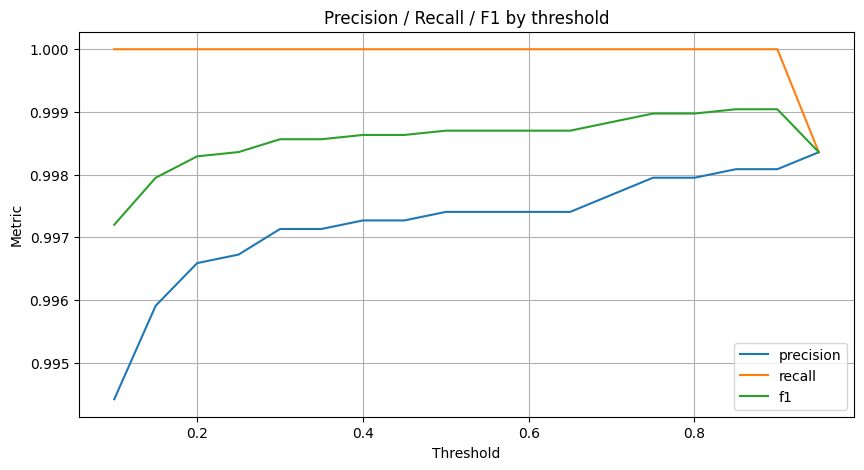

In [7]:
# ============================================================
# PRECISION / RECALL BY THRESHOLD
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(threshold_df["threshold"], threshold_df["precision"], label="precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="f1")

plt.xlabel("Threshold")
plt.ylabel("Metric")
plt.title("Precision / Recall / F1 by threshold")
plt.legend()
plt.grid(True)

plt.show()

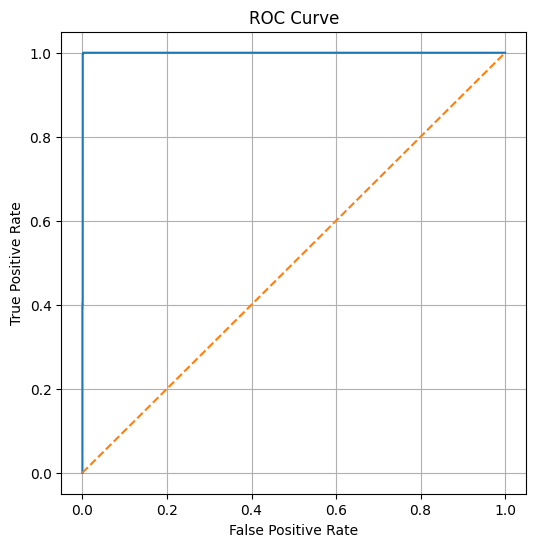

In [9]:
# ============================================================
# ROC CURVE
# ============================================================

fpr, tpr, _ = roc_curve(y_true, y_score)

plt.figure(figsize=(6, 6))

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.grid(True)

plt.show()

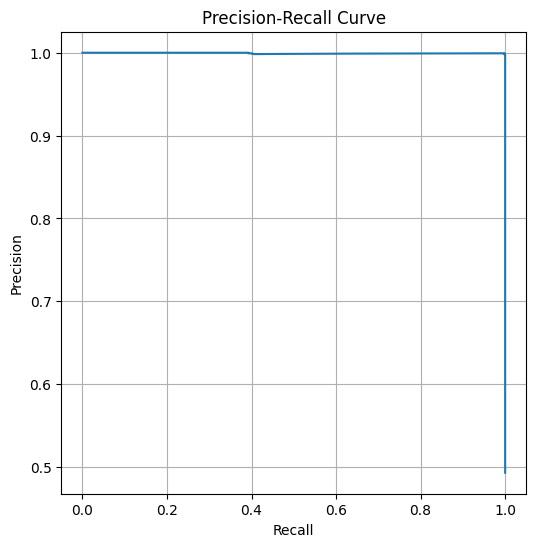

In [10]:
# ============================================================
# PRECISION-RECALL CURVE
# ============================================================

precision, recall, _ = precision_recall_curve(y_true, y_score)

plt.figure(figsize=(6, 6))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)

plt.show()

In [11]:
# ============================================================
# FALSE POSITIVES
# ============================================================

false_positives = test_predictions[
    (test_predictions["label"] == 0)
    &
    (test_predictions["prediction"] == 1)
].copy()

print(f"False positives: {len(false_positives):,}")

display(
    false_positives[
        [
            "party_name_1",
            "party_name_2",
            "name_latin_1",
            "name_latin_2",
            "score",
            "pair_type",
            "fuzz_ratio",
            "token_set_ratio",
            "core_token_set_ratio",
            "token_jaccard",
        ]
    ]
    .sort_values("score", ascending=False)
    .head(30)
)

False positives: 19


,party_name_1,party_name_2,name_latin_1,name_latin_2,score,pair_type,fuzz_ratio,token_set_ratio,core_token_set_ratio,token_jaccard
652,Амонов Одинаҳмад Нуруллоевич,Амонов Одинахмад Нуруллоевич,amonov odinaҳmad nurulloevich,amonov odinahmad nurulloevich,0.999957,hard_negative_similar_name,96.551724,96.551724,96.551724,0.500000
14299,Амонов Одинахмад Нуруллоевич,Амонов Одинаҳмад Нуруллоевич,amonov odinahmad nurulloevich,amonov odinaҳmad nurulloevich,0.999957,hard_negative_similar_name,96.551724,96.551724,96.551724,0.500000
2794,Амонов Одинахмад Нуруллоевич,Амонов Одинаҳмад Нуруллоевич,amonov odinahmad nurulloevich,amonov odinaҳmad nurulloevich,0.999947,hard_negative_similar_name,96.551724,96.551724,96.551724,0.500000
7286,Амонов Одинахмад Нуруллоевич,Амонов Одинаҳмад Нуруллоевич,amonov odinahmad nurulloevich,amonov odinaҳmad nurulloevich,0.999947,hard_negative_similar_name,96.551724,96.551724,96.551724,0.500000
10771,Абдуллоев Начмиддин Хайруллоевич,Абдуллоев Начмиддин Хайруллоевич,abdulloev nachmiddin hai rulloevich,abdulloev nachmiddin hai rulloevich,0.999946,hard_negative_similar_name,100.000000,100.000000,100.000000,1.000000
7424,Абдулаев Абдумуталиб Пулатжанович,Абдулоев Абдумуталиб Пулатжанович,abdulaev abdumutalib pulatzhanovich,abduloev abdumutalib pulatzhanovich,0.993577,hard_negative_similar_name,97.142857,97.142857,97.142857,0.500000
9812,Абдурахмонов Ашраф Ниматҷонович,Абдурахмонов Ашраф Ниматчонович,abdurahmonov ashraf nimatҷonovich,abdurahmonov ashraf nimatchonovich,0.989587,hard_negative_similar_name,95.522388,95.522388,95.522388,0.500000
3882,Абдурахмонов Ашраф Ниматҷонович,Абдурахмонов Ашраф Ниматчонович,abdurahmonov ashraf nimatҷonovich,abdurahmonov ashraf nimatchonovich,0.989220,hard_negative_similar_name,95.522388,95.522388,95.522388,0.500000
13149,Аминов Абулхайр Иброҳимович,Аминов Абдулхайр Иброхимович,aminov abulhai r ibroҳimovich,aminov abdulhai r ibrohimovich,0.973993,hard_negative_similar_name,94.915254,94.915254,94.915254,0.333333
3703,Аминов Абдулхайр Иброхимович,Аминов Абулхайр Иброҳимович,aminov abdulhai r ibrohimovich,aminov abulhai r ibroҳimovich,0.968026,hard_negative_similar_name,94.915254,94.915254,94.915254,0.333333


In [12]:
# ============================================================
# FALSE NEGATIVES
# ============================================================

false_negatives = test_predictions[
    (test_predictions["label"] == 1)
    &
    (test_predictions["prediction"] == 0)
].copy()

print(f"False negatives: {len(false_negatives):,}")

display(
    false_negatives[
        [
            "party_name_1",
            "party_name_2",
            "name_latin_1",
            "name_latin_2",
            "score",
            "pair_type",
            "fuzz_ratio",
            "token_set_ratio",
            "core_token_set_ratio",
            "token_jaccard",
        ]
    ]
    .sort_values("score")
    .head(30)
)

False negatives: 0


,party_name_1,party_name_2,name_latin_1,name_latin_2,score,pair_type,fuzz_ratio,token_set_ratio,core_token_set_ratio,token_jaccard


In [13]:
# ============================================================
# ERROR TYPES
# ============================================================

def classify_error(row):
    if row["label"] == row["prediction"]:
        return "correct"

    if row["label"] == 0 and row["prediction"] == 1:
        if row["token_jaccard"] >= 0.5:
            return "false_positive_similar_names"
        return "false_positive_other"

    if row["label"] == 1 and row["prediction"] == 0:
        if row["core_token_set_ratio"] < 90:
            return "false_negative_low_name_similarity"
        return "false_negative_threshold"

    return "unknown"


test_predictions["error_type"] = test_predictions.apply(
    classify_error,
    axis=1,
)

print(test_predictions["error_type"].value_counts())

error_type
correct                         14793
false_positive_similar_names       14
false_positive_other                5
Name: count, dtype: int64


In [14]:
# ============================================================
# EVALUATION ON PAIR TYPES
# ============================================================

pair_type_rows = []

for pair_type, subset in test_predictions.groupby("pair_type"):
    if subset["label"].nunique() < 2:
        roc_auc = None
    else:
        roc_auc = roc_auc_score(subset["label"], subset["score"])

    pair_type_rows.append(
        {
            "pair_type": pair_type,
            "rows": len(subset),
            "precision": precision_score(subset["label"], subset["prediction"], zero_division=0),
            "recall": recall_score(subset["label"], subset["prediction"], zero_division=0),
            "f1": f1_score(subset["label"], subset["prediction"], zero_division=0),
            "roc_auc": roc_auc,
        }
    )

pair_type_metrics = pd.DataFrame(pair_type_rows)

display(pair_type_metrics)

,pair_type,rows,precision,recall,f1,roc_auc
0,easy_negative_different_public_id,7372,0.0,0.0,0.0,None
1,hard_negative_similar_name,135,0.0,0.0,0.0,None
2,positive_same_public_id,7305,1.0,1.0,1.0,None


In [15]:
# ============================================================
# CLUSTER EXPORT QUALITY
# ============================================================

canonical_entities = pd.read_parquet(
    "../data/processed/canonical_entities_full_sample.parquet"
)

deduplicated_sample = pd.read_parquet(
    "../data/processed/deduplicated_sample.parquet"
)

print(f"Deduplicated records: {len(deduplicated_sample):,}")
print(f"Canonical entities: {len(canonical_entities):,}")

summary = {
    "input_records": len(deduplicated_sample),
    "final_entities": len(canonical_entities),
    "singleton_entities": (canonical_entities["cluster_size"] == 1).sum(),
    "non_singleton_entities": (canonical_entities["cluster_size"] > 1).sum(),
    "records_in_duplicate_clusters": canonical_entities.loc[
        canonical_entities["cluster_size"] > 1,
        "cluster_size",
    ].sum(),
    "deduplication_compression": 1 - len(canonical_entities) / len(deduplicated_sample),
}

cluster_summary_df = pd.DataFrame([summary])

display(cluster_summary_df)

Deduplicated records: 89,133
Canonical entities: 75,690


,input_records,final_entities,singleton_entities,non_singleton_entities,records_in_duplicate_clusters,deduplication_compression
0,89133,75690,69737,5953,19396,0.15082


In [16]:
# ============================================================
# SAVE EVALUATION RESULTS
# ============================================================

metrics_df.to_parquet(
    "../data/processed/final_test_metrics.parquet",
    index=False,
)

threshold_df.to_parquet(
    "../data/processed/threshold_sweep.parquet",
    index=False,
)

pair_type_metrics.to_parquet(
    "../data/processed/pair_type_metrics.parquet",
    index=False,
)

cluster_summary_df.to_parquet(
    "../data/processed/final_cluster_summary.parquet",
    index=False,
)

test_predictions.to_parquet(
    "../data/processed/final_test_predictions_with_errors.parquet",
    index=False,
)

print("Saved evaluation artifacts.")

Saved evaluation artifacts.
